In [2]:
import sys
repo_root = r"E:\yan0\multi-sample-disentangle\baseline\scNiche-main"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import scniche as sn
print(sn.__version__)

import scanpy as sc
import pandas as pd
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Last run with scNiche version:", sn.__version__)
sn.pp.set_seed()

d:\anaconda3\envs\disent\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
d:\anaconda3\envs\disent\Lib\site-packages\torch\cuda\__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


1.1.1+local
Last run with scNiche version: 1.1.1+local


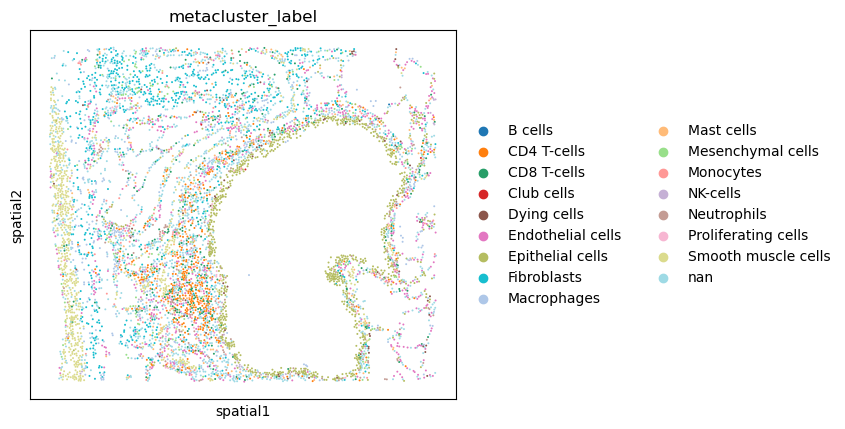

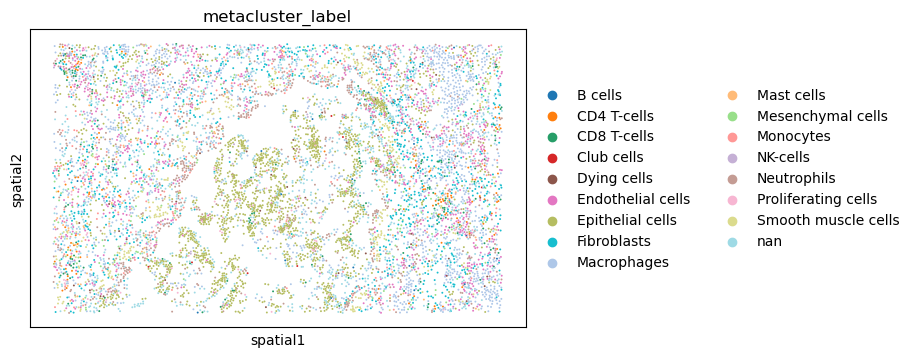

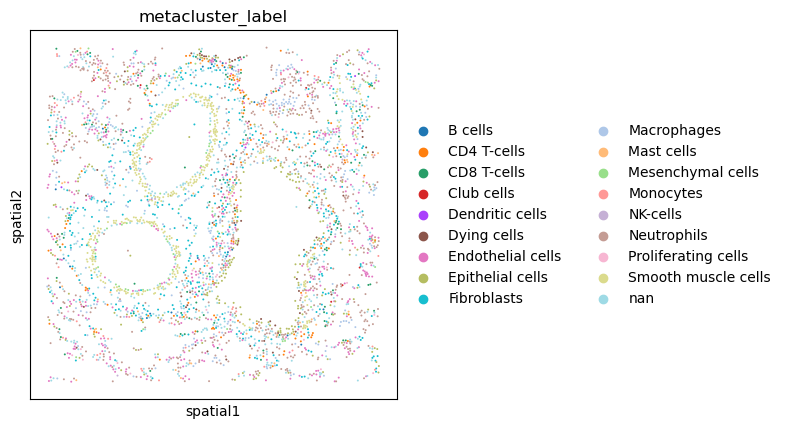

In [3]:
adata = sc.read_h5ad('E:/yan0/multi-sample-disentangle/multi-sample-data/UTAG/infected_lung_adata.h5ad')

Batch_list  = []
adj_list    = []

adata1 = adata[adata.obs['disease']=='Healthy']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[21]]
sc.pl.spatial(adata2, img_key="hires", color=["metacluster_label"], spot_size=10, show=False)
Batch_list.append(adata2)

adata1 = adata[adata.obs['disease'] == 'ARDS']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[27]]
sc.pl.spatial(adata2, img_key="hires", color=["metacluster_label"], spot_size=10, show=False)
Batch_list.append(adata2)

adata1 = adata[adata.obs['disease'] == 'COVID19']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[39]]
sc.pl.spatial(adata2, img_key="hires", color=["metacluster_label"], spot_size=10, show=False)
Batch_list.append(adata2)

In [4]:
for adata in Batch_list:
    adata.obsm['feat'] = adata.X

In [5]:
import anndata as ad
section_ids = [1,2,3]
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')

In [6]:
adata = adata_concat.copy()

In [7]:
cell_type_key = 'metacluster_label'
sample_key = 'batch_name'
use_rep = 'feat'
k_cutoff = 6
lr = 0.01
epochs = 100
batch_num = 3

In [8]:
adata

AnnData object with n_obs × n_vars = 19711 × 43
    obs: 'roi', 'sample', 'disease', 'phenotypes', 'acquisition_id', 'acquisition_date', 'obj_id', 'cluster_1.0', 'cluster_label', 'metacluster_label', 'X', 'Y', 'slice_name', 'batch_name'
    obsm: 'X_pca', 'X_umap', 'spatial', 'feat'

In [9]:
# prepare multi slices
adata = sn.pp.process_multi_slices(
    adata=adata_concat,
    celltype_key=cell_type_key,
    sample_key=sample_key,
    mode='KNN',
    k_cutoff=k_cutoff,
    is_pca=False,
    verbose=False,
    layer_key=use_rep
)

# choose the features of the three views `X_C2L`, `X_data`, and `X_data_nbr` to run scNiche     
choose_views = ['X_data', 'X_data_nbr']
adata = sn.pp.prepare_data_batch(adata=adata, verbose=False, batch_num=batch_num, choose_views=choose_views)

# training
model = sn.tr.Runner_batch(adata=adata, device='cuda:0', verbose=False, choose_views=choose_views)
adata = model.fit(lr=0.01, epochs=epochs)

# clustering
target_num = 6
adata = sn.tr.clustering(adata=adata, target_k=target_num)

-------Process 3 slices...


100%|██████████| 3/3 [00:02<00:00,  1.40it/s]

Applying K-Means Clustering with 6 target cluster numbers...


In [15]:
adata

AnnData object with n_obs × n_vars = 19711 × 43
    obs: 'roi', 'sample', 'disease', 'phenotypes', 'acquisition_id', 'acquisition_date', 'obj_id', 'cluster_1.0', 'cluster_label', 'metacluster_label', 'X', 'Y', 'slice_name', 'batch_name', 'scNiche'
    uns: 'CN_order', 'batch_idx', 'dataloader', 'loss'
    obsm: 'X_pca', 'X_umap', 'spatial', 'feat', 'X_cn', 'X_cn_norm', 'X_data', 'X_data_nbr', 'X_scniche'

In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score

# 保存到 scNiche 目录
save_dir = r"E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering"
os.makedirs(save_dir, exist_ok=True)

Batch_list1 = []
for section_id in section_ids:
    Batch_list1.append(adata_concat[adata_concat.obs["batch_name"] == section_id])

spot_size = 15
title_size = 12

# 计算每个样本 ARI
n_batches = len(Batch_list1)
ARI_list = []
for bb in range(n_batches):
    ARI_list.append(
        round(
            ari_score(
                Batch_list1[bb].obs["Ground Truth"],
                Batch_list1[bb].obs["mclust"],
            ),
            2,
        )
    )

# 分别保存每个 sample 的单图：无 legend + 黑边框
for bb in range(n_batches):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    sc.pl.spatial(
        Batch_list1[bb],
        img_key=None,
        color=["mclust"],
        title=[""],
        legend_loc=None,   # 不显示 legend
        show=False,
        ax=ax,
        frameon=True,      # 开启边框
        spot_size=spot_size,
    )

    # ARI 标题
    # ax.set_title(f"ARI={ARI_list[bb]}", size=title_size)

    # 去坐标轴信息（如要保留可删）
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 黑色边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    out_path = os.path.join(save_dir, f"sample_{bb+1}_mclust.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {out_path}")

In [31]:
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import adjusted_rand_score as ari_score

# =========================
# save path
# =========================
save_dir = r"E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering"
os.makedirs(save_dir, exist_ok=True)

# =========================
# split slices
# =========================
slice_ids = list(adata.obs[sample_key].unique())
Batch_list_sn = [adata[adata.obs[sample_key] == sid].copy() for sid in slice_ids]

spot_size = 15
ncols_legend = 6  # legend横排列数

# =========================
# rename scNiche labels -> Niche1, Niche2, ...
# =========================
for ad in Batch_list_sn:
    labels = ad.obs["scNiche"].astype(str)
    uniq = labels.unique().tolist()

    if all(x.isdigit() for x in uniq):
        uniq_sorted = sorted(uniq, key=lambda x: int(x))
    else:
        uniq_sorted = sorted(uniq)

    label_map = {old: f"Niche{i+1}" for i, old in enumerate(uniq_sorted)}
    ad.obs["scNiche_plot"] = labels.map(label_map).astype("category")

# =========================
# ARI per slice (optional, 6 decimals)
# =========================
ARI_list = []
for ad in Batch_list_sn:
    ari = float(ari_score(ad.obs[cell_type_key], ad.obs["scNiche"]))
    ARI_list.append(round(ari, 6))

# =========================
# plot/save each slice
# =========================
for i, ad in enumerate(Batch_list_sn):
    fig, ax = plt.subplots(1, 1, figsize=(7.0, 6.0), dpi=300)

    # draw points (no scanpy legend)
    sc.pl.spatial(
        ad,
        img_key=None,               # 有组织图像可改为 "hires"
        color=["scNiche_plot"],
        title=[""],
        legend_loc=None,
        show=False,
        ax=ax,
        frameon=True,
        spot_size=spot_size,
    )

    # categories & colors
    s = ad.obs["scNiche_plot"]
    cats = list(s.cat.categories)

    # scanpy会把颜色写到 uns["scNiche_plot_colors"]
    colors = ad.uns.get("scNiche_plot_colors", None)
    if colors is None or len(colors) < len(cats):
        cmap = plt.get_cmap("tab10")
        colors = [cmap(j % 10) for j in range(len(cats))]
    else:
        colors = list(colors)[:len(cats)]

    # circular legend handles
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=10,
            markerfacecolor=colors[j],
            markeredgecolor="none",
            label=str(cats[j]),
        )
        for j in range(len(cats))
    ]

    ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=min(ncols_legend, len(cats)),
        frameon=False,
        fontsize=9,
        bbox_transform=ax.transAxes,
        borderaxespad=0.0,
    )

    # remove axis info
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # black frame
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # space for legend
    fig.subplots_adjust(bottom=0.18)

    out_path = os.path.join(save_dir, f"slice_{i+1}_scNiche.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {out_path} | ARI={ARI_list[i]:.6f}")

Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering\slice_1_scNiche.png | ARI=0.223944
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering\slice_2_scNiche.png | ARI=0.282146
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering\slice_3_scNiche.png | ARI=0.174475


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score as ari_score

# ========= 1) 重新计算 scNiche 三个 slice 的 ARI =========
slice_ids = list(adata.obs[sample_key].unique())[:3]
Batch_list_sn = [adata[adata.obs[sample_key] == sid].copy() for sid in slice_ids]

ari_values = []
for ad in Batch_list_sn:
    ari_values.append(float(ari_score(ad.obs[cell_type_key], ad.obs["scNiche"])))

# ========= 2) 写入统一 metrics/ari.csv =========
method_name = "scNiche"
metrics_dir = r"E:\yan0\multi-sample-disentangle\results\lung_infected\metrics"
os.makedirs(metrics_dir, exist_ok=True)
csv_path = os.path.join(metrics_dir, "ari.csv")

vals = ari_values[:3] + [np.nan] * max(0, 3 - len(ari_values))

new_row = pd.DataFrame([{
    "method": method_name,
    "sample1_ari": vals[0],
    "sample2_ari": vals[1],
    "sample3_ari": vals[2],
}])

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    if "method" in df.columns and (df["method"] == method_name).any():
        df.loc[df["method"] == method_name, ["sample1_ari", "sample2_ari", "sample3_ari"]] = vals
    else:
        df = pd.concat([df, new_row], ignore_index=True)
else:
    df = new_row

# 固定6位小数保存
df.to_csv(csv_path, index=False, encoding="utf-8-sig", float_format="%.6f")

print("Saved:", csv_path)
print("scNiche ARI:", [f"{x:.6f}" for x in ari_values])

Saved: E:\yan0\multi-sample-disentangle\results\lung_infected\metrics\ari.csv
scNiche ARI: ['0.223944', '0.282146', '0.174475']


: 

In [30]:
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import adjusted_rand_score as ari_score

# =========================
# save path
# =========================
save_dir = r"E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering"
os.makedirs(save_dir, exist_ok=True)

# =========================
# split slices
# =========================
slice_ids = list(adata.obs[sample_key].unique())
Batch_list_sn = [adata[adata.obs[sample_key] == sid].copy() for sid in slice_ids]

spot_size = 15
title_size = 12
ncols_legend = 6  # legend横排列数，可按类别数量调大/调小

# =========================
# ARI per slice (6 decimals)
# =========================
ARI_list = []
for ad in Batch_list_sn:
    ari = float(ari_score(ad.obs[cell_type_key], ad.obs["scNiche"]))
    ARI_list.append(round(ari, 6))

# =========================
# plot/save each slice
# =========================
for i, ad in enumerate(Batch_list_sn):
    fig, ax = plt.subplots(1, 1, figsize=(7.0, 6.0), dpi=300)

    # 先用scanpy画点（关闭自带legend）
    sc.pl.spatial(
        ad,
        img_key=None,          # 有组织图像可改成 "hires"
        color=["scNiche"],
        title=[""],
        legend_loc=None,       # 关闭scanpy legend，后面手动画圆点legend
        show=False,
        ax=ax,
        frameon=True,
        spot_size=spot_size,
    )

    # 可选：标题（ARI）
    # ax.set_title(f"ARI={ARI_list[i]:.6f}", size=title_size)

    # 获取类别与颜色（颜色来自scanpy写入的uns）
    s = ad.obs["scNiche"]
    if hasattr(s, "cat"):
        cats = list(s.cat.categories)
    else:
        cats = sorted(s.astype(str).unique().tolist())

    colors = ad.uns.get("scNiche_colors", None)
    if colors is None or len(colors) < len(cats):
        cmap = plt.get_cmap("tab10")
        colors = [cmap(j % 10) for j in range(len(cats))]
    else:
        colors = list(colors)[:len(cats)]

    # 手工圆点 legend（不是方块）
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=10,
            markerfacecolor=colors[j],
            markeredgecolor="none",
            label=str(cats[j]),
        )
        for j in range(len(cats))
    ]

    ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=min(ncols_legend, len(cats)),
        frameon=False,
        fontsize=9,
        bbox_transform=ax.transAxes,
        borderaxespad=0.0,
    )

    # 去坐标信息
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 黑色边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # 给底部legend留空间
    fig.subplots_adjust(bottom=0.18)

    out_path = os.path.join(save_dir, f"slice_{i+1}_scNiche.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {out_path}")

Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering\slice_1_scNiche.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering\slice_2_scNiche.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/scNiche/clustering\slice_3_scNiche.png


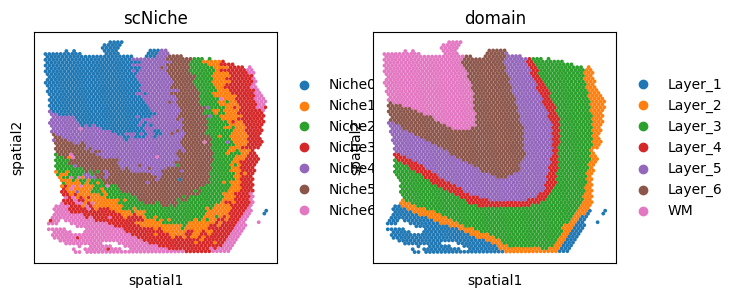

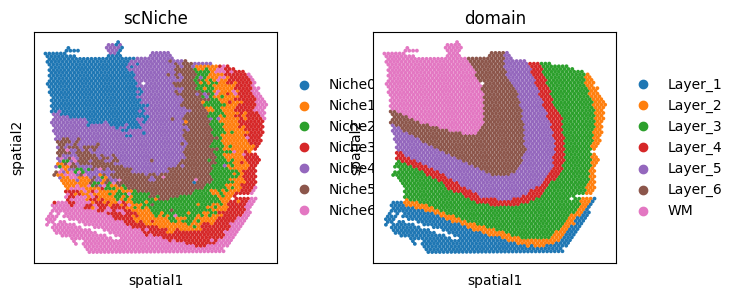

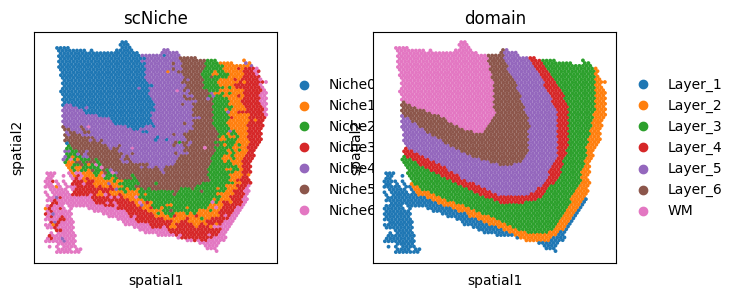

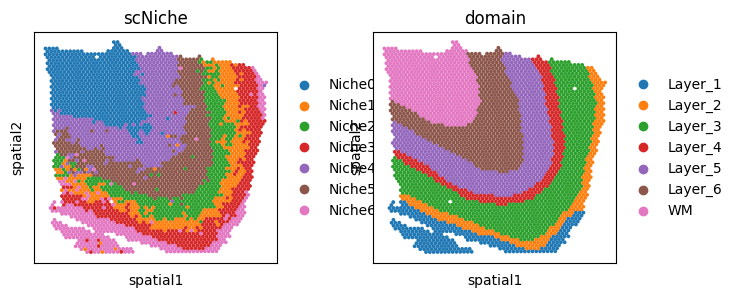

In [4]:
for i in ['151673', '151674', '151675', '151676']:
    plt.rcParams["figure.figsize"] = (3, 3)
    sc.pl.embedding(adata[adata.obs['slice'] == 'slice' + i], basis="spatial", color=['scNiche', 'domain'],s=30, )

In [5]:
res = adata.obs.copy()
for i in ['151673', '151674', '151675', '151676']:
    res_tmp = res.loc[res['slice'] == 'slice' + i]
    a = res_tmp['domain'].values
    b = res_tmp['scNiche'].values
            
    # ari
    ari_tmp = adjusted_rand_score(a, b)
    
    print(f"slice {i} - ARI: {ari_tmp}")

slice 151673 - ARI: 0.5343164681501748
slice 151674 - ARI: 0.5545313905213357
slice 151675 - ARI: 0.5810943154142099
slice 151676 - ARI: 0.548507847272454
